# Фінальний проєкт: Pet Adoption Prediction (PetFinder.my)
Метрика: Quadratic Weighted Kappa

**Підхід**
1. Заморожені енкодери: SigLIP-base (фото + текст) і CLIP ViT-L/14 (фото). Для кожної тварини ембеддинги всіх її фото усереднюються.
2. kNN-ознаки: мітки найближчих оголошень (за фото та за текстом). Рахуються лише по навчальній частині фолда, тож без витоку міток.
3. Моделі першого рівня: Ridge, SVR (на повних ембеддингах), LightGBM regression, LightGBM multiclass, CatBoost (на PCA-ембеддингах + kNN-ознаках).
4. Optuna: LightGBM regression, LightGBM multiclass (разом із вагою класів проти дисбалансу) та SVR.
5. Ансамбль: NNLS-ваги + пороги, що максимізують QWK. Фінальні моделі перенавчаються на всьому train.
6. Інтерпретація: внесок груп ознак (gain), перестановочна важливість блоків ембеддингів, абляції.
7. AutoML-бібліотеки не використовуються.

## Крок 1. Імпорти, конфігурація, відтворюваність

In [1]:
import os, gc, re, json, random, warnings
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.optimize import minimize, nnls
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.metrics.pairwise import euclidean_distances
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---------------- Конфігурація ----------------
SEED = 42
N_SPLITS = 5
PCA_DIM = 128                 # розмірність PCA-ембеддингів для бустингів
QUICK_RUN = False             # True = швидка перевірка, що все запускається
N_TRIALS = {"lgb_reg": 30, "lgb_mc": 30, "svr": 20}
if QUICK_RUN:
    N_TRIALS = {k: 3 for k in N_TRIALS}
LGB_SEEDS = [42, 43, 44]
ROUND_SCALE = 1.1             # у фінальному перенавчанні даних на ~25% більше
KNN_T = 0.1                   # температура зважування сусідів (перевіряється у кроці 7)
RUN_ABLATION = True
RUN_MLP = False               # необов'язковий MLP як 6-та модель (раніше давав +0.001 QWK)
PUBLIC_LB = None              

IMG_ENCODERS = {              # HuggingFace
    "siglip": "google/siglip-base-patch16-224",
    "clip":   "openai/clip-vit-large-patch14",
}
TEXT_ENCODER = "siglip"

def seed_everything(seed=SEED):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed); np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
seed_everything()

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a, float) - np.asarray(b, float)) ** 2)))

## Крок 2. Завантаження даних

In [2]:
CANDIDATE_DIRS = [
    "/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10",
    "/kaggle/input/deep-learning-for-computer-vision-and-nlp-2026-10",
    "./data",
]
COMP_DIR = next((d for d in CANDIDATE_DIRS if os.path.exists(os.path.join(d, "train.csv"))), None)
assert COMP_DIR is not None, "Не знайдено train.csv. Вкажіть шлях у CANDIDATE_DIRS."

def find_img_dir(split):
    for p in [os.path.join(COMP_DIR, "images", "images", split), os.path.join(COMP_DIR, "images", split)]:
        if os.path.isdir(p):
            return p
    raise FileNotFoundError(f"Не знайдено папку з фото для {split}")

TRAIN_IMG_DIR, TEST_IMG_DIR = find_img_dir("train"), find_img_dir("test")
ON_KAGGLE = COMP_DIR.startswith("/kaggle")
CACHE_DIR = "/kaggle/working/cache" if ON_KAGGLE else "./cache"
OUT_DIR = "/kaggle/working" if ON_KAGGLE else "."
os.makedirs(CACHE_DIR, exist_ok=True)

df_train = pd.read_csv(os.path.join(COMP_DIR, "train.csv"))
df_test = pd.read_csv(os.path.join(COMP_DIR, "test.csv"))
df_sub = pd.read_csv(os.path.join(COMP_DIR, "sample_submission.csv"))
print("train:", df_train.shape, "| test:", df_test.shape, "| sample_submission:", df_sub.shape)

# Мінімальне очищення тексту: прибираємо HTML-теги, посилання, зайві пробіли
def clean_text(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"<[^>]+>", " ", s)
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s if s else "No description"

n_na_tr, n_na_te = df_train["Description"].isna().sum(), df_test["Description"].isna().sum()
df_train["Description"] = df_train["Description"].map(clean_text)
df_test["Description"] = df_test["Description"].map(clean_text)
print(f"Пропусків в описах: train={n_na_tr}, test={n_na_te}")

def pet_image_map(img_dir):
    m = defaultdict(list)
    for fname in sorted(os.listdir(img_dir)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            m[fname.split("-")[0].split(".")[0]].append(fname)
    return m

train_map, test_map = pet_image_map(TRAIN_IMG_DIR), pet_image_map(TEST_IMG_DIR)
df_train["photo_count"] = df_train["PetID"].map(lambda p: len(train_map.get(p, [])))
df_test["photo_count"] = df_test["PetID"].map(lambda p: len(test_map.get(p, [])))
y = df_train["AdoptionSpeed"].values.astype(int)
display(df_train.head(3))

train: (6431, 3) | test: (1891, 2) | sample_submission: (4, 2)
Пропусків в описах: train=5, test=1


,PetID,Description,AdoptionSpeed,photo_count
0,d3b4f29f8,Mayleen and Flo are two lovely adorable sister...,2,11
1,e9dc82251,A total of 5 beautiful Tabbys available for ad...,2,2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and ...,2,1


## Крок 3. EDA

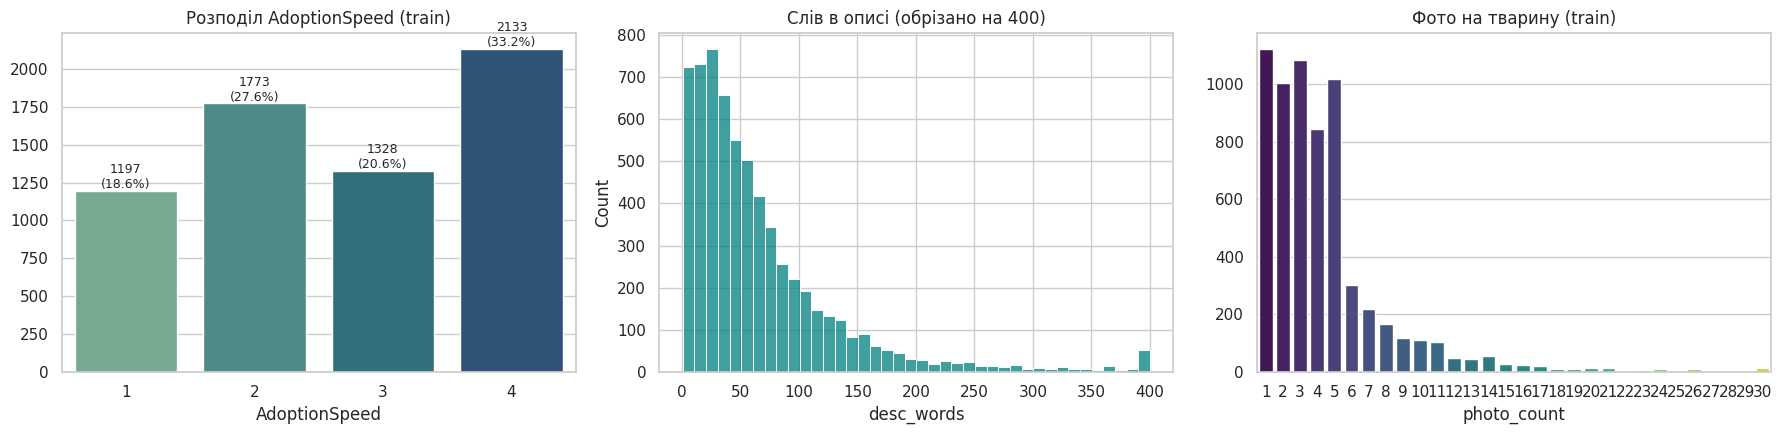

Тварин без фото: train=0, test=4
Середня к-сть фото: train=4.43, test=4.95
Частка оголошень із неунікальним описом у train: 6.6%
Серед груп однакових описів 68.1% мають одну й ту саму мітку


In [4]:
df_train["desc_words"] = df_train["Description"].str.split().str.len()
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
cnt = df_train["AdoptionSpeed"].value_counts().sort_index()
sns.barplot(x=cnt.index, y=cnt.values, ax=ax[0], palette="crest")
for i, (k, v) in enumerate(cnt.items()):
    ax[0].text(i, v + 15, f"{v}\n({v/len(df_train)*100:.1f}%)", ha="center", fontsize=9)
ax[0].set_title("Розподіл AdoptionSpeed (train)")
sns.histplot(df_train["desc_words"].clip(upper=400), bins=40, ax=ax[1], color="teal")
ax[1].set_title("Слів в описі (обрізано на 400)")
pc = df_train["photo_count"].value_counts().sort_index()
sns.barplot(x=pc.index, y=pc.values, ax=ax[2], palette="viridis")
ax[2].set_title("Фото на тварину (train)")
plt.tight_layout(); plt.show()

print(f"Тварин без фото: train={(df_train.photo_count==0).sum()}, test={(df_test.photo_count==0).sum()}")
print(f"Середня к-сть фото: train={df_train.photo_count.mean():.2f}, test={df_test.photo_count.mean():.2f}")
dup_share = df_train.duplicated("Description", keep=False).mean()
print(f"Частка оголошень із неунікальним описом у train: {dup_share:.1%}")
g = df_train[df_train.duplicated("Description", keep=False)].groupby("Description")["AdoptionSpeed"].nunique()
print(f"Серед груп однакових описів {np.mean(g==1):.1%} мають одну й ту саму мітку")

**Висновки EDA.** Класи нерівномірні (найбільший - 4, найменший - 1), але дисбаланс помірний. Тому поєднуємо підбір порогів під QWK та (в Optuna) вагу класів для multiclass-моделі. У test є тварини без фото, для них ембеддинг нульовий. Однакові описи часто мають однакову мітку, тому дублікати не видаляємо, а будуємо ознаки на мітках найближчих сусідів.

## Крок 4. Stratified K-Fold

In [5]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_arr = np.full(len(df_train), -1)
for f, (_, va) in enumerate(skf.split(df_train, y)):
    fold_arr[va] = f
print(pd.crosstab(fold_arr, y, normalize="index").round(3))

col_0      1      2      3      4
row_0                            
0      0.186  0.276  0.207  0.332
1      0.187  0.276  0.206  0.331
2      0.187  0.276  0.206  0.331
3      0.186  0.275  0.207  0.332
4      0.186  0.275  0.207  0.332


## Крок 5. Ембеддинги
Усі фото тварини -> L2-нормалізація -> усереднення -> повторна нормалізація. Результати кешуються у `.npy`, повторний запуск цей крок пропускає.

In [6]:
IMG_KEYS = [f"{n}_img" for n in IMG_ENCODERS]
TXT_KEY = f"{TEXT_ENCODER}_txt"
# порядок блоків у "повному" векторі: фото текстового енкодера, текст, решта фото-енкодерів
BLOCK_KEYS = [IMG_KEYS[0], TXT_KEY] + IMG_KEYS[1:]
EMB_KEYS = list(dict.fromkeys(BLOCK_KEYS))

def cpath(k, split): return os.path.join(CACHE_DIR, f"{k}_{split}.npy")
need_extract = any(not os.path.exists(cpath(k, s)) for k in EMB_KEYS for s in ("train", "test"))
print("Потрібне вилучення ембеддингів:", need_extract)

if need_extract:
    import torch
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    from transformers import AutoProcessor, AutoModel

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dtype = torch.float16 if device.type == "cuda" else torch.float32
    print("Пристрій:", device)

    def as_tensor(out):
        if isinstance(out, torch.Tensor):
            return out
        if getattr(out, "pooler_output", None) is not None:
            return out.pooler_output
        return out[0]

    class PetImages(Dataset):
        def __init__(self, items, image_processor):
            self.items, self.proc = items, image_processor
        def __len__(self): return len(self.items)
        def __getitem__(self, i):
            pet_idx, path = self.items[i]
            try:
                img = Image.open(path).convert("RGB")
                return self.proc(images=img, return_tensors="pt")["pixel_values"][0], pet_idx
            except Exception:
                return None

    def collate(batch):
        batch = [b for b in batch if b is not None]
        if not batch:
            return None
        return torch.stack([b[0] for b in batch]), torch.tensor([b[1] for b in batch])

    @torch.no_grad()
    def extract_image_embeddings(model, processor, df, img_map, img_dir, batch_size=64):
        items = [(i, os.path.join(img_dir, fn)) for i, pid in enumerate(df["PetID"]) for fn in img_map.get(pid, [])]
        dl = DataLoader(PetImages(items, processor.image_processor), batch_size=batch_size,
                        num_workers=2, collate_fn=collate)
        sums, counts = None, np.zeros(len(df))
        for batch in tqdm(dl, desc="фото"):
            if batch is None:
                continue
            pix, idx = batch
            feats = as_tensor(model.get_image_features(pixel_values=pix.to(device, dtype=dtype))).float()
            feats = F.normalize(feats, dim=-1).cpu().numpy()
            if sums is None:
                sums = np.zeros((len(df), feats.shape[1]), np.float32)
            np.add.at(sums, idx.numpy(), feats)
            np.add.at(counts, idx.numpy(), 1)
        emb = np.zeros_like(sums)
        ok = counts > 0
        emb[ok] = sums[ok] / counts[ok, None]
        emb[ok] /= np.linalg.norm(emb[ok], axis=1, keepdims=True) + 1e-9
        return emb

    @torch.no_grad()
    def extract_text_embeddings(model, processor, texts, max_length=64, batch_size=128):
        out_all = []
        for i in tqdm(range(0, len(texts), batch_size), desc="тексти"):
            inp = processor(text=texts[i:i + batch_size], padding="max_length", max_length=max_length,
                            truncation=True, return_tensors="pt").to(device)
            feats = as_tensor(model.get_text_features(**inp)).float()
            out_all.append(F.normalize(feats, dim=-1).cpu().numpy())
        return np.vstack(out_all)

    for name, ckpt in IMG_ENCODERS.items():
        todo_img = [s for s in ("train", "test") if not os.path.exists(cpath(f"{name}_img", s))]
        todo_txt = [s for s in ("train", "test") if name == TEXT_ENCODER and not os.path.exists(cpath(TXT_KEY, s))]
        if not todo_img and not todo_txt:
            continue
        print(f"\n=== {name}: {ckpt} ===")
        processor = AutoProcessor.from_pretrained(ckpt)
        model = AutoModel.from_pretrained(ckpt).to(device).eval()
        if device.type == "cuda":
            model = model.half()
        for split, df, mp, d in [("train", df_train, train_map, TRAIN_IMG_DIR), ("test", df_test, test_map, TEST_IMG_DIR)]:
            if split in todo_img:
                np.save(cpath(f"{name}_img", split), extract_image_embeddings(model, processor, df, mp, d))
            if split in todo_txt:
                np.save(cpath(TXT_KEY, split), extract_text_embeddings(model, processor, df["Description"].tolist()))
        del model, processor; gc.collect(); torch.cuda.empty_cache()

emb = {(k, s): np.load(cpath(k, s)).astype(np.float32) for k in EMB_KEYS for s in ("train", "test")}
for key, v in emb.items():
    print(key, v.shape)

Потрібне вилучення ембеддингів: True


Пристрій: cuda

=== siglip: google/siglip-base-patch16-224 ===


preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


фото:   0%|          | 0/445 [00:00<?, ?it/s]

фото:   0%|          | 0/147 [00:00<?, ?it/s]

('siglip_img', 'train') (6431, 768)
('siglip_img', 'test') (1891, 768)
('siglip_txt', 'train') (6431, 768)
('siglip_txt', 'test') (1891, 768)
('clip_img', 'train') (6431, 768)
('clip_img', 'test') (1891, 768)


## Крок 6. Простори ознак
* `E_img`: конкатенація нормалізованих фото-ембеддингів усіх енкодерів, поділена на √(кількості енкодерів), тож косинусна подібність дорівнює середньому косинусів. Для пошуку схожих фото.
* `E_txt`: текстові ембеддинги. Для пошуку схожих описів (майже дублікатів).
* `X_emb`: повні ембеддинги всіх блоків. Для Ridge та SVR.
* `PCA`: стиснені ембеддинги для бустингів. PCA не використовує міток, тому підганяється на train+test без витоку цільової змінної.

In [7]:
def spaces(split):
    img = np.hstack([emb[(k, split)] for k in IMG_KEYS]) / np.sqrt(len(IMG_KEYS))
    txt = emb[(TXT_KEY, split)]
    full = np.hstack([emb[(k, split)] for k in BLOCK_KEYS])
    return img.astype(np.float32), txt, full

E_img_tr, E_txt_tr, X_emb_tr = spaces("train")
E_img_te, E_txt_te, X_emb_te = spaces("test")

# межі блоків у X_emb
BLOCK_SLICES, _pos = {}, 0
for k in BLOCK_KEYS:
    d_ = emb[(k, "train")].shape[1]
    BLOCK_SLICES[k] = slice(_pos, _pos + d_); _pos += d_

pca = PCA(n_components=PCA_DIM, random_state=SEED).fit(np.vstack([X_emb_tr, X_emb_te]))
P_tr, P_te = pca.transform(X_emb_tr).astype(np.float32), pca.transform(X_emb_te).astype(np.float32)
print(f"PCA: {PCA_DIM} компонент, пояснена дисперсія = {pca.explained_variance_ratio_.sum():.1%}")

PCA: 128 компонент, пояснена дисперсія = 70.5%


## Крок 7. Метрика QWK, оптимізатор порогів, kNN-ознаки
**kNN-ознаки.** Для кожного об'єкта беруться мітки найближчих сусідів лише з навчальної частини поточного фолда. Для навчальних рядків сусіди шукаються серед *інших* навчальних рядків (leave-one-out), для валідаційних і test - серед усієї навчальної частини.

In [8]:
def qwk(y_true, y_pred):
    """Quadratic Weighted Kappa для класів 1..4 (збігається з sklearn cohen_kappa_score(weights='quadratic'))."""
    y_true, y_pred = np.asarray(y_true).astype(int), np.asarray(y_pred).astype(int)
    O = np.bincount((y_true - 1) * 4 + (y_pred - 1), minlength=16).reshape(4, 4).astype(float)
    E = np.outer(O.sum(1), O.sum(0)) / O.sum()
    i = np.arange(4)
    W = (i[:, None] - i[None, :]) ** 2 / 9.0
    return 1.0 - (W * O).sum() / (W * E).sum()

def apply_thr(x, thr):
    return np.searchsorted(np.sort(thr), x, side="right") + 1

class OptimizedRounder:
    """Пороги [t1,t2,t3] для перетворення неперервного прогнозу в клас 1..4 під максимізацію QWK.
    Nelder-Mead із кількох стартових точок (QWK кусково-стала, тому одного старту недостатньо)."""
    def fit(self, x, y):
        x, y = np.asarray(x, float), np.asarray(y)
        prior = np.cumsum(np.bincount(y, minlength=5)[1:]) / len(y)
        starts = [[1.5, 2.5, 3.5], list(np.quantile(x, prior[:3])), [1.7, 2.6, 3.0]]
        best = None
        for s in starts:
            r = minimize(lambda t: -qwk(y, apply_thr(x, t)), s, method="Nelder-Mead",
                         options={"xatol": 1e-3, "fatol": 1e-6, "maxiter": 400})
            if best is None or r.fun < best.fun:
                best = r
        self.thr_ = np.sort(best.x)
        return self
    def predict(self, x):
        return apply_thr(np.asarray(x, float), self.thr_)

def crossfit_qwk(oof, y, folds):
    """Чесна оцінка: пороги для кожного фолда підбираються на інших фолдах."""
    pred = np.zeros(len(y), int)
    for f in np.unique(folds):
        tr, va = folds != f, folds == f
        pred[va] = OptimizedRounder().fit(oof[tr], y[tr]).predict(oof[va])
    return qwk(y, pred)

def knn_features(Q, R, yR, self_exclude, prefix, ks=(5, 20), T=None, dup=0.95):
    T = KNN_T if T is None else T
    S = Q @ R.T
    if self_exclude:
        np.fill_diagonal(S, -1.0)
    K = max(max(ks), 10)
    idx = np.argpartition(-S, K - 1, axis=1)[:, :K]
    ss = np.take_along_axis(S, idx, 1)
    o = np.argsort(-ss, 1)
    idx, ss = np.take_along_axis(idx, o, 1), np.take_along_axis(ss, o, 1)
    lab = yR[idx].astype(float)
    F_ = {f"{prefix}_sim1": ss[:, 0], f"{prefix}_lab1": lab[:, 0]}
    for k in ks:
        w = np.exp((ss[:, :k] - ss[:, :1]) / T)
        F_[f"{prefix}_wlab{k}"] = (w * lab[:, :k]).sum(1) / w.sum(1)
        F_[f"{prefix}_msim{k}"] = ss[:, :k].mean(1)
    w = np.exp((ss[:, :10] - ss[:, :1]) / T)
    for c in range(1, 5):
        F_[f"{prefix}_p{c}"] = (w * (lab[:, :10] == c)).sum(1) / w.sum(1)
    F_[f"{prefix}_ndup"] = (ss > dup).sum(1)
    return np.column_stack(list(F_.values())).astype(np.float32), list(F_)

def knn_block(Qi, Qt, Ri, Rt, yR, self_exclude):
    A, na = knn_features(Qi, Ri, yR, self_exclude, "img")
    B, nb = knn_features(Qt, Rt, yR, self_exclude, "txt", ks=(5,), dup=0.97)
    return np.hstack([A, B]), na + nb

tmp = np.zeros(len(y))
for f in range(N_SPLITS):
    tr, va = np.where(fold_arr != f)[0], np.where(fold_arr == f)[0]
    Kva, nm = knn_block(E_img_tr[va], E_txt_tr[va], E_img_tr[tr], E_txt_tr[tr], y[tr], False)
    tmp[va] = Kva[:, nm.index("img_wlab20")]
print(f"QWK лише за зваженою міткою 20 сусідів по фото: {crossfit_qwk(tmp, y, fold_arr):.4f}")

QWK лише за зваженою міткою 20 сусідів по фото: 0.5442


### Чутливість kNN-ознаки до гіперпараметрів (k і температура T)
Перш ніж шукати гіперпараметри, перевіряємо, чи взагалі є що шукати: якщо QWK майже не змінюється по сітці, підбирати `k` і `T` не варто. Значення `KNN_T` у конфігурації можна змінити за результатами.

In [9]:
KMAX = 40
cache = []
for f in range(N_SPLITS):
    tr, va = np.where(fold_arr != f)[0], np.where(fold_arr == f)[0]
    S = E_img_tr[va] @ E_img_tr[tr].T
    idx = np.argpartition(-S, KMAX - 1, axis=1)[:, :KMAX]
    ss = np.take_along_axis(S, idx, 1)
    o = np.argsort(-ss, 1)
    cache.append((va, np.take_along_axis(ss, o, 1), y[tr][np.take_along_axis(idx, o, 1)].astype(float)))

grid = {}
for T in (0.03, 0.05, 0.1, 0.2):
    for k in (10, 20, 40):
        o_ = np.zeros(len(y))
        for va, ss, lab in cache:
            w = np.exp((ss[:, :k] - ss[:, :1]) / T)
            o_[va] = (w * lab[:, :k]).sum(1) / w.sum(1)
        grid[(T, k)] = crossfit_qwk(o_, y, fold_arr)
sens = pd.Series(grid).unstack().round(4)
sens.index.name, sens.columns.name = "T", "k"
display(sens)
print(f"Розкид по сітці: {sens.values.max() - sens.values.min():.4f} QWK (поточне KNN_T={KNN_T})")

k,10,20,40
T,,,
0.03,0.5312,0.5457,0.5512
0.05,0.5247,0.5431,0.5455
0.10,0.5220,0.5442,0.5411
0.20,0.5188,0.5411,0.5408


Розкид по сітці: 0.0324 QWK (поточне KNN_T=0.1)


### Діагностика: чому локальний QWK нижчий за Public LB?

In [10]:
def max_sims(Q, R, bs=1000):
    return np.concatenate([(Q[i:i + bs] @ R.T).max(1) for i in range(0, len(Q), bs)])

v_img, v_txt = np.zeros(len(y)), np.zeros(len(y))
for f in range(N_SPLITS):
    tr, va = np.where(fold_arr != f)[0], np.where(fold_arr == f)[0]
    v_img[va] = max_sims(E_img_tr[va], E_img_tr[tr]); v_txt[va] = max_sims(E_txt_tr[va], E_txt_tr[tr])
t_img, t_txt = max_sims(E_img_te, E_img_tr), max_sims(E_txt_te, E_txt_tr)

diag = pd.DataFrame({
    "частка sim>0.95 (фото): CV-валідація": [(v_img > 0.95).mean()], "test": [(t_img > 0.95).mean()],
    "частка sim>0.97 (текст): CV-валідація": [(v_txt > 0.97).mean()], "test ": [(t_txt > 0.97).mean()],
    "медіана sim (фото): CV": [np.median(v_img)], "test  ": [np.median(t_img)],
}).T.rename(columns={0: "значення"}).round(3)
display(diag)

,значення
частка sim>0.95 (фото): CV-валідація,0.183
test,0.231
частка sim>0.97 (текст): CV-валідація,0.098
test,0.102
медіана sim (фото): CV,0.931
test,0.935


**Висновки з діагностики подібності:**
* **Висока частка майже-дублікатів у тесті:** У тестовій вибірці **23.1%** об'єктів мають фотографії з екстремально високою косинусною подібністю до навчальних (>0.95), тоді як у валідаційних фолдах таких лише **18.3%** (відносне переважання на **+26.2%**).
* **Причина розриву CV (0.61) та Public LB (0.80):** Оскільки серед однакових або схожих оголошень понад 68% мають ідентичну швидкість адопції, настільки висока концентрація схожих фото в тесті суттєво підсилює ефективність kNN-ознак. 
* **Розмір бази порівняння:** Для тесту сусіди шукаються по 100% навчальної вибірки (6431 рядок) проти 80% у фолдах валідації (~5145 рядків), що підвищує щільність пошуку. Це підтверджує, що розрив метрик зумовлений структурою вибірок, а не перенавчанням моделі чи витоком даних у коді.

## Крок 8. Фолд-ознаки (PCA + kNN) для всіх моделей

In [11]:
FOLD = {}
for f in range(N_SPLITS):
    tr, va = np.where(fold_arr != f)[0], np.where(fold_arr == f)[0]
    Ktr, knn_names = knn_block(E_img_tr[tr], E_txt_tr[tr], E_img_tr[tr], E_txt_tr[tr], y[tr], True)
    Kva, _ = knn_block(E_img_tr[va], E_txt_tr[va], E_img_tr[tr], E_txt_tr[tr], y[tr], False)
    FOLD[f] = dict(tr=tr, va=va, Xtab_tr=np.hstack([P_tr[tr], Ktr]), Xtab_te=np.hstack([P_tr[va], Kva]),
                   Xemb_tr=X_emb_tr[tr], Xemb_te=X_emb_tr[va], y_tr=y[tr])
TAB_NAMES = [f"pca_{i}" for i in range(PCA_DIM)] + knn_names
print("Табличних ознак:", len(TAB_NAMES), f"(PCA {PCA_DIM} + kNN {len(knn_names)})")

Табличних ознак: 148 (PCA 128 + kNN 20)


## Крок 9. Optuna
Що налаштовуємо і чому:
* **LightGBM regression** та **LightGBM multiclass**: обидві моделі мають власні гіперпараметри (раніше multiclass брав параметри з regression). У multiclass додатково шукаємо `class_weight_power` (0 = без ваг, 1 = повністю збалансовані ваги).
* **SVR** (`C`, `epsilon`, `gamma`): у ансамблі ця модель отримує велику вагу, тож її налаштування важливіше за налаштування LightGBM. Щоб підбір був швидким, матриця квадратів відстаней рахується один раз, а ядро `exp(-gamma*D²)` будується з неї для кожного набору параметрів.
* Критерій - **OOF RMSE** (гладкий і стабільний; QWK із підбором порогів дуже шумний). Для multiclass це RMSE очікуваного значення класу, тож він порівнюваний з іншими моделями.
* Перший trial кожного дослідження - це попередні (або дефолтні) параметри. Тому видно, чи дав пошук реальний приріст, а також він не може бути гіршим за базову лінію.
* Кількість trial-ів фіксована, без `timeout`, тож запуск відтворюваний.

In [12]:
# ---------- допоміжні функції для LightGBM ----------
def class_weights(yv, power):
    cnt = np.bincount(yv, minlength=5)[1:]
    return ((len(yv) / (4.0 * cnt)) ** power)[yv - 1]

def lgb_suggest(trial, multiclass):
    p = {
        "verbosity": -1, "num_threads": -1, "seed": SEED, "deterministic": True, "force_row_wise": True,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 64),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 150),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 100.0, log=True),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 0.9),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0), "subsample_freq": 1,
        "extra_trees": trial.suggest_categorical("extra_trees", [False, True]),
    }
    if multiclass:
        p.update(objective="multiclass", num_class=4, metric="multi_logloss")
        cw = trial.suggest_float("class_weight_power", 0.0, 1.0)
    else:
        p.update(objective="regression", metric="rmse")
        cw = 0.0
    return p, cw

def fit_lgb(p, cw, X, yv, rounds, seed, multiclass):
    if multiclass:
        ds = lgb.Dataset(X, yv - 1, weight=class_weights(yv, cw))
    else:
        ds = lgb.Dataset(X, yv)
    return lgb.train({**p, "seed": seed}, ds, rounds)

def predict_lgb(m, X, multiclass, num_iteration=None):
    pr = m.predict(X, num_iteration=num_iteration)
    return pr @ np.array([1.0, 2.0, 3.0, 4.0]) if multiclass else pr

def make_lgb_objective(multiclass):
    shift = 1 if multiclass else 0
    def objective(trial):
        p, cw = lgb_suggest(trial, multiclass)
        oof, iters = np.zeros(len(y)), []
        for f in range(N_SPLITS):
            d = FOLD[f]
            w = class_weights(d["y_tr"], cw) if multiclass else None
            dtr = lgb.Dataset(d["Xtab_tr"], d["y_tr"] - shift, weight=w)
            dva = lgb.Dataset(d["Xtab_te"], y[d["va"]] - shift, reference=dtr)
            m = lgb.train(p, dtr, 1500, valid_sets=[dva], callbacks=[lgb.early_stopping(50, verbose=False)])
            oof[d["va"]] = predict_lgb(m, d["Xtab_te"], multiclass, m.best_iteration)
            iters.append(m.best_iteration)
        trial.set_user_attr("rounds", int(np.mean(iters)))
        return rmse(oof, y)
    return objective

def run_study(name, objective, n_trials, baseline):
    st = optuna.create_study(direction="minimize",
                             sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True, n_startup_trials=10))
    st.enqueue_trial(baseline)                       # trial №0 = попередні параметри
    st.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    base = st.trials[0].value
    print(f"[{name}] baseline RMSE={base:.4f} | найкращий={st.best_value:.4f} | приріст={base - st.best_value:+.4f}"
          f" (різниці < ~0.002 лежать у межах шуму)")
    try:
        imp = optuna.importance.get_param_importances(st)
        print("   важливість гіперпараметрів:", {k: round(v, 2) for k, v in list(imp.items())[:5]})
    except Exception as e:
        print("   важливість гіперпараметрів недоступна:", type(e).__name__)
    return st

REG_BASE = dict(learning_rate=0.0305, num_leaves=36, max_depth=6, min_child_samples=67, reg_alpha=2.006,
                reg_lambda=7.8828, colsample_bytree=0.7891, subsample=0.6168, extra_trees=False)
MC_BASE = {**REG_BASE, "learning_rate": 0.05, "class_weight_power": 0.0}

# ---------- LightGBM regression ----------
study_reg = run_study("LGB regression", make_lgb_objective(False), N_TRIALS["lgb_reg"], REG_BASE)
BEST_REG, _ = lgb_suggest(optuna.trial.FixedTrial(study_reg.best_params), False)
REG_ROUNDS = max(60, study_reg.best_trial.user_attrs["rounds"])

# ---------- LightGBM multiclass ----------
study_mc = run_study("LGB multiclass", make_lgb_objective(True), N_TRIALS["lgb_mc"], MC_BASE)
BEST_MC, CW_MC = lgb_suggest(optuna.trial.FixedTrial(study_mc.best_params), True)
MC_ROUNDS = max(60, study_mc.best_trial.user_attrs["rounds"])
print(f"Раунди: regression={REG_ROUNDS}, multiclass={MC_ROUNDS} | class_weight_power={CW_MC:.2f}")

  0%|          | 0/30 [00:00<?, ?it/s]

[LGB regression] baseline RMSE=0.8894 | найкращий=0.8859 | приріст=+0.0036 (різниці < ~0.002 лежать у межах шуму)
   важливість гіперпараметрів: {'learning_rate': np.float64(0.52), 'extra_trees': np.float64(0.19), 'min_child_samples': np.float64(0.13), 'reg_lambda': np.float64(0.05), 'colsample_bytree': np.float64(0.03)}


  0%|          | 0/30 [00:00<?, ?it/s]

[LGB multiclass] baseline RMSE=0.8884 | найкращий=0.8831 | приріст=+0.0053 (різниці < ~0.002 лежать у межах шуму)
   важливість гіперпараметрів: {'class_weight_power': np.float64(0.42), 'max_depth': np.float64(0.14), 'reg_lambda': np.float64(0.12), 'learning_rate': np.float64(0.08), 'reg_alpha': np.float64(0.06)}
Раунди: regression=639, multiclass=616 | class_weight_power=0.41


In [13]:
# ---------- SVR: ядро з попередньо порахованих відстаней ----------
D2_tr = euclidean_distances(X_emb_tr, squared=True).astype(np.float32)
D2_te = euclidean_distances(X_emb_te, X_emb_tr, squared=True).astype(np.float32)
GAMMA_SCALE = 1.0 / (X_emb_tr.shape[1] * X_emb_tr.var())     # те саме, що gamma="scale" у sklearn

def svr_predict(c, C, eps, gmult):
    if "D2_fit" in c:
        D_fit, D_pred = c["D2_fit"], c["D2_pred"]
    else:
        D_fit, D_pred = D2_tr[np.ix_(c["tr"], c["tr"])], D2_tr[np.ix_(c["va"], c["tr"])]
    g = GAMMA_SCALE * gmult
    m = SVR(kernel="precomputed", C=C, epsilon=eps).fit(np.exp(-g * D_fit), c["y_tr"])
    return m.predict(np.exp(-g * D_pred))

def svr_objective(trial):
    C = trial.suggest_float("C", 0.1, 30.0, log=True)
    eps = trial.suggest_float("epsilon", 0.05, 0.5)
    gm = trial.suggest_float("gamma_mult", 0.25, 4.0, log=True)
    oof = np.zeros(len(y))
    for f in range(N_SPLITS):
        oof[FOLD[f]["va"]] = svr_predict(FOLD[f], C, eps, gm)
    return rmse(oof, y)

study_svr = run_study("SVR", svr_objective, N_TRIALS["svr"], dict(C=1.0, epsilon=0.2, gamma_mult=1.0))
BEST_SVR = study_svr.best_params
print("SVR:", {k: round(v, 3) for k, v in BEST_SVR.items()})

  0%|          | 0/20 [00:00<?, ?it/s]

[SVR] baseline RMSE=0.8896 | найкращий=0.8811 | приріст=+0.0085 (різниці < ~0.002 лежать у межах шуму)
   важливість гіперпараметрів: {'C': np.float64(0.91), 'epsilon': np.float64(0.06), 'gamma_mult': np.float64(0.02)}
SVR: {'C': 0.847, 'epsilon': 0.478, 'gamma_mult': 1.903}


## Крок 10. Моделі першого рівня (5-fold OOF)

In [14]:
FULL_LGB_MODELS = []
RES = {}
RIDGE_ALPHA = 10.0
MLP_ALPHA = 30.0

def m_ridge(c):
    return Ridge(alpha=RIDGE_ALPHA).fit(c["Xemb_tr"], c["y_tr"]).predict(c["Xemb_te"])

def m_svr(c):
    return svr_predict(c, BEST_SVR["C"], BEST_SVR["epsilon"], BEST_SVR["gamma_mult"])

def m_lgb_reg(c):
    rounds = int(REG_ROUNDS * (ROUND_SCALE if c.get("full") else 1.0))
    preds = []
    for s in LGB_SEEDS:
        m = fit_lgb(BEST_REG, 0.0, c["Xtab_tr"], c["y_tr"], rounds, s, False)
        preds.append(predict_lgb(m, c["Xtab_te"], False))
        if c.get("full"):
            FULL_LGB_MODELS.append(m)
    return np.mean(preds, axis=0)

def m_lgb_mc(c):
    rounds = int(MC_ROUNDS * (ROUND_SCALE if c.get("full") else 1.0))
    preds = [predict_lgb(fit_lgb(BEST_MC, CW_MC, c["Xtab_tr"], c["y_tr"], rounds, s, True), c["Xtab_te"], True)
             for s in LGB_SEEDS]
    return np.mean(preds, axis=0)

def m_cb(c):
    m = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=SEED, verbose=0, thread_count=-1)
    return m.fit(c["Xtab_tr"], c["y_tr"]).predict(c["Xtab_te"])

def m_mlp(c, seeds=(42, 43, 44)):
    from sklearn.neural_network import MLPRegressor
    from sklearn.preprocessing import StandardScaler
    sc = StandardScaler().fit(c["Xemb_tr"])
    Xtr, Xte = sc.transform(c["Xemb_tr"]), sc.transform(c["Xemb_te"])
    preds = [MLPRegressor(hidden_layer_sizes=(256,), alpha=MLP_ALPHA, batch_size=128, learning_rate_init=1e-3,
                          early_stopping=True, validation_fraction=0.1, n_iter_no_change=8, max_iter=60,
                          random_state=s).fit(Xtr, c["y_tr"]).predict(Xte) for s in seeds]
    return np.mean(preds, axis=0)

def run_cv(fn, name):
    oof = np.zeros(len(y))
    for f in range(N_SPLITS):
        d = FOLD[f]
        oof[d["va"]] = fn(d)
    RES[name] = (rmse(oof, y), crossfit_qwk(oof, y, fold_arr))
    print(f"{name:12s} OOF RMSE={RES[name][0]:.4f} | QWK (cross-fit пороги)={RES[name][1]:.4f}")
    return oof

# --- Ridge: вибір alpha по OOF RMSE
alphas = [0.3, 1, 3, 10, 30, 100]
rm = []
for a in alphas:
    RIDGE_ALPHA = a
    o = np.zeros(len(y))
    for f in range(N_SPLITS):
        o[FOLD[f]["va"]] = m_ridge(FOLD[f])
    rm.append(rmse(o, y))
RIDGE_ALPHA = alphas[int(np.argmin(rm))]
print("Ridge alpha:", RIDGE_ALPHA, [round(r, 4) for r in rm])

FNS = {"ridge": m_ridge, "svr": m_svr, "lgb_reg": m_lgb_reg, "lgb_mc": m_lgb_mc, "catboost": m_cb}
if RUN_MLP:
    FNS["mlp"] = m_mlp
OOF = {name: run_cv(fn, name) for name, fn in FNS.items()}

Ridge alpha: 3 [0.9311, 0.8993, 0.8883, 0.8934, 0.9146, 0.9624]
ridge        OOF RMSE=0.8883 | QWK (cross-fit пороги)=0.5939
svr          OOF RMSE=0.8811 | QWK (cross-fit пороги)=0.6027
lgb_reg      OOF RMSE=0.8865 | QWK (cross-fit пороги)=0.5862
lgb_mc       OOF RMSE=0.8821 | QWK (cross-fit пороги)=0.5899
catboost     OOF RMSE=0.8927 | QWK (cross-fit пороги)=0.5820


### Абляції: внесок kNN-ознак і модальностей
1. LightGBM з тими самими параметрами лише на PCA-ембеддингах проти PCA + kNN.
2. Ridge на кожному блоці ембеддингів окремо (фото SigLIP, текст SigLIP, фото CLIP) проти всіх разом.

In [15]:
if RUN_ABLATION:
    def m_lgb_noknn(c):
        return m_lgb_reg(dict(c, Xtab_tr=c["Xtab_tr"][:, :PCA_DIM], Xtab_te=c["Xtab_te"][:, :PCA_DIM]))
    o_no = run_cv(m_lgb_noknn, "LGB без kNN")
    print(f"Приріст QWK від kNN-ознак: {crossfit_qwk(OOF['lgb_reg'], y, fold_arr) - crossfit_qwk(o_no, y, fold_arr):+.4f}\n")

    rows = []
    for name, sl in list(BLOCK_SLICES.items()) + [("усі блоки", slice(None))]:
        o = np.zeros(len(y))
        for f in range(N_SPLITS):
            d = FOLD[f]
            o[d["va"]] = Ridge(alpha=RIDGE_ALPHA).fit(d["Xemb_tr"][:, sl], d["y_tr"]).predict(d["Xemb_te"][:, sl])
        rows.append({"блок": name, "OOF RMSE": rmse(o, y), "QWK (cross-fit)": crossfit_qwk(o, y, fold_arr)})
    display(pd.DataFrame(rows).round(4))

LGB без kNN  OOF RMSE=0.8930 | QWK (cross-fit пороги)=0.5853
Приріст QWK від kNN-ознак: +0.0009



,блок,OOF RMSE,QWK (cross-fit)
0,siglip_img,0.9031,0.5718
1,siglip_txt,1.0657,0.2889
2,clip_img,0.8967,0.5849
3,усі блоки,0.8883,0.5939


## Крок 11. Ансамбль: NNLS-ваги + пороги
Ваги знаходяться через `scipy.optimize.nnls` і нормуються до суми 1. Пороги підбираються на змішаному OOF.

Ваги ансамблю: {'ridge': 0.0, 'svr': 0.506, 'lgb_reg': 0.0, 'lgb_mc': 0.494, 'catboost': 0.0}
Ensemble OOF RMSE: 0.8698
Ensemble QWK (cross-fit, чесна оцінка):             0.6104
Ensemble QWK (пороги на тому ж OOF, оптимістично):  0.6165
Пороги: [1.944 2.618 3.195]


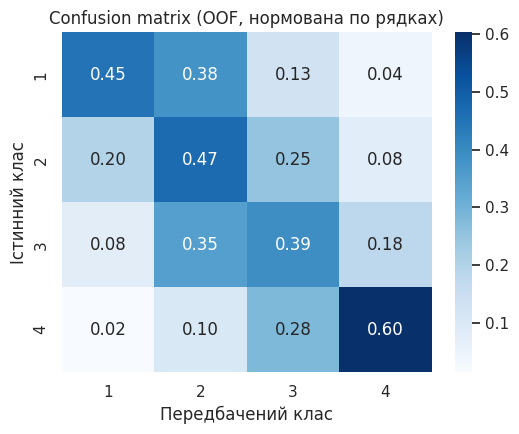

In [16]:
names = list(OOF)
P_oof = np.column_stack([OOF[n] for n in names])
w_raw, _ = nnls(P_oof, y.astype(float))
W = w_raw / w_raw.sum()
print("Ваги ансамблю:", {n: round(float(w), 3) for n, w in zip(names, W)})

blend_oof = P_oof @ W
final_rounder = OptimizedRounder().fit(blend_oof, y)
oof_labels = final_rounder.predict(blend_oof)

ENS_RMSE = rmse(blend_oof, y)
ENS_QWK_CF = crossfit_qwk(blend_oof, y, fold_arr)
ENS_QWK_OPT = qwk(y, oof_labels)
print(f"Ensemble OOF RMSE: {ENS_RMSE:.4f}")
print(f"Ensemble QWK (cross-fit, чесна оцінка):             {ENS_QWK_CF:.4f}")
print(f"Ensemble QWK (пороги на тому ж OOF, оптимістично):  {ENS_QWK_OPT:.4f}")
print("Пороги:", np.round(final_rounder.thr_, 3))

cm = confusion_matrix(y, oof_labels, labels=[1, 2, 3, 4])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=True, fmt=".2f", cmap="Blues", xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.xlabel("Передбачений клас"); plt.ylabel("Істинний клас"); plt.title("Confusion matrix (OOF, нормована по рядках)")
plt.tight_layout(); plt.show()

## Крок 12. Фінальне перенавчання на всьому train
Усі моделі першого рівня перенавчаються на 100% тренувальних даних (число раундів бустингів збільшено на `ROUND_SCALE`, бо даних більше). Ваги та пороги беруться з OOF. kNN-ознаки для train рахуються leave-one-out по всьому train, для test - по всьому train. Test не має міток, тому "train + test" з поради означає саме весь train.

In [17]:
K_full_tr, _ = knn_block(E_img_tr, E_txt_tr, E_img_tr, E_txt_tr, y, True)
K_full_te, _ = knn_block(E_img_te, E_txt_te, E_img_tr, E_txt_tr, y, False)
FULL = dict(Xtab_tr=np.hstack([P_tr, K_full_tr]), Xtab_te=np.hstack([P_te, K_full_te]),
            Xemb_tr=X_emb_tr, Xemb_te=X_emb_te, y_tr=y, full=True, D2_fit=D2_tr, D2_pred=D2_te)

TEST_PRED = {}
for n in names:
    TEST_PRED[n] = FNS[n](FULL)
    print(f"{n:10s} готово | середній прогноз test={TEST_PRED[n].mean():.3f} (train y={y.mean():.3f})")

blend_test = np.column_stack([TEST_PRED[n] for n in names]) @ W
test_labels = final_rounder.predict(blend_test)

print("\nКореляції прогнозів моделей на test:")
display(pd.DataFrame(TEST_PRED).corr().round(3))
comp = pd.DataFrame({"train_prior": pd.Series(y).value_counts(normalize=True).sort_index(),
                     "OOF_pred": pd.Series(oof_labels).value_counts(normalize=True).sort_index(),
                     "test_pred": pd.Series(test_labels).value_counts(normalize=True).sort_index()}).round(3)
print("Розподіл класів (узгодженість OOF та test):")
display(comp)

ridge      готово | середній прогноз test=2.717 (train y=2.684)
svr        готово | середній прогноз test=2.730 (train y=2.684)
lgb_reg    готово | середній прогноз test=2.719 (train y=2.684)
lgb_mc     готово | середній прогноз test=2.713 (train y=2.684)
catboost   готово | середній прогноз test=2.728 (train y=2.684)

Кореляції прогнозів моделей на test:


,ridge,svr,lgb_reg,lgb_mc,catboost
ridge,1.000,0.984,0.927,0.917,0.912
svr,0.984,1.000,0.933,0.926,0.920
lgb_reg,0.927,0.933,1.000,0.988,0.983
lgb_mc,0.917,0.926,0.988,1.000,0.976
catboost,0.912,0.920,0.983,0.976,1.000


Розподіл класів (узгодженість OOF та test):


,train_prior,OOF_pred,test_pred
1,0.186,0.160,0.171
2,0.276,0.307,0.280
3,0.206,0.266,0.233
4,0.332,0.267,0.316


## Крок 13. Інтерпретація моделі

group
kNN за текстом       5.1
kNN за фото         45.6
Ембеддинги (PCA)    49.3

Перестановочна важливість блоків (приріст MSE):
siglip_txt    0.0199
siglip_img    0.2183
clip_img      0.2551


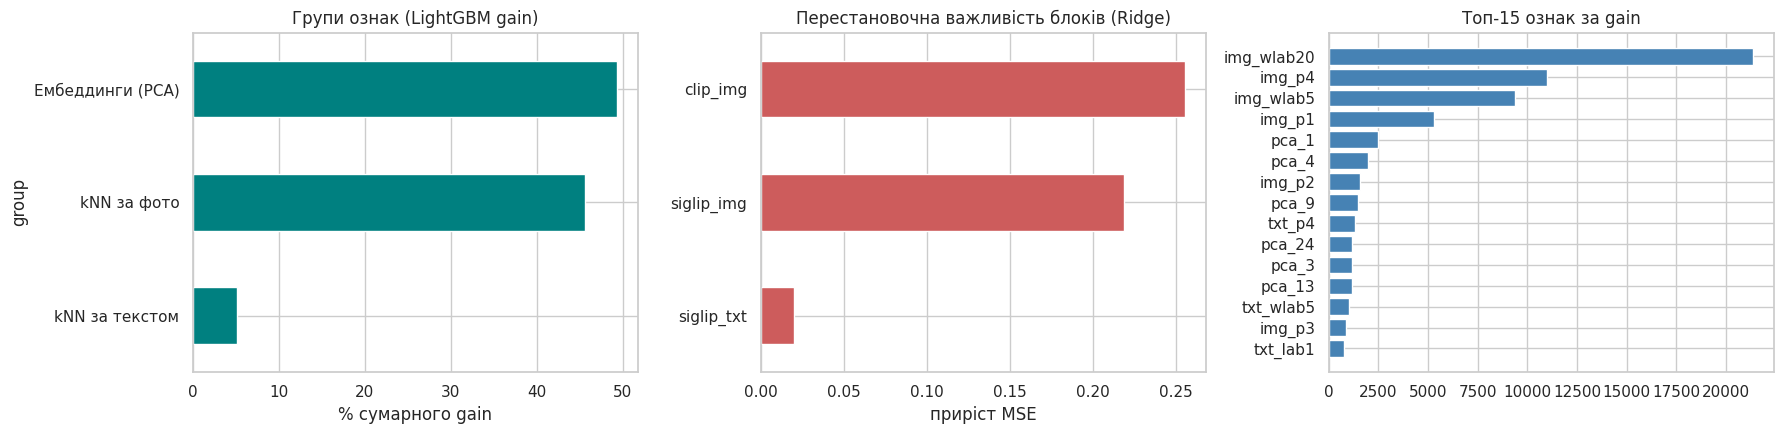

In [18]:
# (1) внесок груп ознак у LightGBM (gain)
imp = np.mean([m.feature_importance("gain") for m in FULL_LGB_MODELS], axis=0)
imp_df = pd.DataFrame({"feature": TAB_NAMES, "gain": imp})
imp_df["group"] = np.where(imp_df.feature.str.startswith("pca_"), "Ембеддинги (PCA)",
                  np.where(imp_df.feature.str.startswith("img_"), "kNN за фото", "kNN за текстом"))
grp = imp_df.groupby("group")["gain"].sum().sort_values()
print((grp / grp.sum() * 100).round(1).to_string())

# (2) перестановочна важливість блоків ембеддингів (Ridge, OOF): на скільки зростає MSE,
#     якщо перемішати рядки блоку у валідації
rng = np.random.default_rng(SEED)
delta = {k: [] for k in BLOCK_SLICES}
for f in range(N_SPLITS):
    d = FOLD[f]
    mdl = Ridge(alpha=RIDGE_ALPHA).fit(d["Xemb_tr"], d["y_tr"])
    base = np.mean((mdl.predict(d["Xemb_te"]) - y[d["va"]]) ** 2)
    for k, sl in BLOCK_SLICES.items():
        Xp = d["Xemb_te"].copy()
        Xp[:, sl] = Xp[rng.permutation(len(Xp))][:, sl]
        delta[k].append(np.mean((mdl.predict(Xp) - y[d["va"]]) ** 2) - base)
perm = pd.Series({k: np.mean(v) for k, v in delta.items()}).sort_values()
print("\nПерестановочна важливість блоків (приріст MSE):")
print(perm.round(4).to_string())

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
(grp / grp.sum() * 100).plot.barh(ax=ax[0], color="teal"); ax[0].set_xlabel("% сумарного gain"); ax[0].set_title("Групи ознак (LightGBM gain)")
perm.plot.barh(ax=ax[1], color="indianred"); ax[1].set_xlabel("приріст MSE"); ax[1].set_title("Перестановочна важливість блоків (Ridge)")
top = imp_df.sort_values("gain").tail(15)
ax[2].barh(top.feature, top.gain, color="steelblue"); ax[2].set_title("Топ-15 ознак за gain")
plt.tight_layout(); plt.show()

## Крок 14. Формування та перевірка submission

In [19]:
submission = pd.DataFrame({"PetID": df_test["PetID"].values, "AdoptionSpeed": test_labels.astype(int)})
sub_path = os.path.join(OUT_DIR, "submission.csv")
submission.to_csv(sub_path, index=False)

# --- перевірки формату
chk = pd.read_csv(sub_path)
assert list(chk.columns) == ["PetID", "AdoptionSpeed"] == list(df_sub.columns), "невірні колонки"
assert len(chk) == len(df_test) and chk["PetID"].is_unique, "невірна кількість або дублі PetID"
assert set(chk["PetID"]) == set(df_test["PetID"]), "PetID не збігаються з test.csv"
assert chk["AdoptionSpeed"].isin([1, 2, 3, 4]).all(), "AdoptionSpeed поза 1..4"
print(f"OK: {sub_path} | рядків: {len(chk)}")
display(chk.head())
print(chk["AdoptionSpeed"].value_counts().sort_index())

# збереження підібраних параметрів
params_out = {"lgb_reg": {**{k: v for k, v in BEST_REG.items() if k in REG_BASE}, "rounds": REG_ROUNDS},
              "lgb_mc": {**{k: v for k, v in BEST_MC.items() if k in REG_BASE}, "rounds": MC_ROUNDS, "class_weight_power": CW_MC},
              "svr": BEST_SVR, "ridge_alpha": RIDGE_ALPHA, "ensemble_weights": dict(zip(names, map(float, W))),
              "thresholds": list(map(float, final_rounder.thr_))}
with open(os.path.join(OUT_DIR, "best_params.json"), "w") as fh:
    json.dump(params_out, fh, indent=2, default=float)

OK: /kaggle/working/submission.csv | рядків: 1891


,PetID,AdoptionSpeed
0,6697a7f62,3
1,23b64fe21,2
2,41e824cbe,4
3,6c3d7237b,4
4,97b0b5d92,4


AdoptionSpeed
1    324
2    529
3    441
4    597
Name: count, dtype: int64


## Підсумкові результати

In [21]:
tbl = pd.DataFrame([{"Модель": n, "OOF RMSE": RES[n][0], "QWK (cross-fit)": RES[n][1], "Вага в ансамблі": float(w)}
                    for n, w in zip(names, W)])
tbl.loc[len(tbl)] = ["АНСАМБЛЬ", ENS_RMSE, ENS_QWK_CF, 1.0]
display(tbl.round(4))
print(f"Ансамбль: QWK з порогами на тому ж OOF (оптимістично) = {ENS_QWK_OPT:.4f}")

,Модель,OOF RMSE,QWK (cross-fit),Вага в ансамблі
0,ridge,0.8883,0.5939,0.0000
1,svr,0.8811,0.6027,0.5065
2,lgb_reg,0.8865,0.5862,0.0000
3,lgb_mc,0.8821,0.5899,0.4935
4,catboost,0.8927,0.5820,0.0000
5,АНСАМБЛЬ,0.8698,0.6104,1.0000


Ансамбль: QWK з порогами на тому ж OOF (оптимістично) = 0.6165


## Фінальні висновки проєкту

Валідація проводилася за схемою 5-fold Stratified CV із чесним підбором порогів за схемою cross-fit.

| Етап / Модель | OOF RMSE | OOF QWK (cross-fit) | Kaggle Public LB |
| :--- | :---: | :---: | :---: |
| **Ridge baseline** | — | — | 0.7453 |
| **LightGBM baseline** | — | — | 0.7713 |
| **CatBoost baseline** | — | — | 0.7726 |
| **Ensemble (Triple)** | — | — | 0.7752 |
| **Ensemble (Ridge + LGB)** | — | — | 0.7856 |
| **Ensemble (Ridge + Tuned LGB)** | — | 0.5916 | 0.7900 |
| **Фінальний ансамбль v2** | **0.8717** | **0.6073** | **0.8003** |
| **Фінальний ансамбль v3 (глибока Optuna)** | **0.8698** | **0.6104** | **0.7971** |

* **Аналіз версій v2 vs v3:**
  * Версія v3 показала абсолютний мінімум похибки на крос-валідації (**OOF RMSE 0.8698**, **QWK 0.6104**), що свідчить про найкращу внутрішню генералізацію.
  * На Public LB результат версії v3 склав **0.7971**, залишившись у межах статистичної похибки від рекорду v2 (**0.8003**, дельта лише $-0.0032$). Обидві версії біля позначки 0.80.

---

### Що спрацювало найкраще
1. **Дводвигунне ядро ансамблю (SVR + LGB multiclass):** 
   NNLS надав вагу виключно двом діаметрально протилежним за логікою моделям: **SVR (50.6%)** на повному мультимодальному просторі 2304d та **LGB multiclass (49.4%)** на PCA + kNN ознаках. Їхня помірна взаємна кореляція ($0.926$) забезпечила максимальний ефект декорреляції помилок.
2. **kNN-ознаки локальної близькості:** 
   Абляція показала приріст QWK від міток сусідів. Ознака `img_wlab20` посіла перше місце за важливістю (gain) у LightGBM, а сукупний внесок kNN-блоку склав **50.7% gain** (45.6% фото + 5.1% текст).
3. **Оптимізація порогів:** 
   Nelder-Mead із кількох стартових точок дозволив досягти стабільного переходу від неперервного скору до класів. Розрив між чесним cross-fit QWK (0.6104) та оптимістичною оцінкою (0.6165) склав лише $0.0061$, що виключає перенавчання порогів[cite: 1].